### Artificial Neural Networking using PyTorch

- Dataset: Fashion MNIST from Kaggle
  - 70,000 Training data
  - Grayscale
  - Each has dimension of 28 \* 28

#### Process

We will use CPU to train the model with this dataset. It will be quite heavy for the CPU to make it done. So we will extract 6000 data from the dataset for the time being


#### Architectural Overview

Input Layer:

- Total number of features - 784
- Hidden layers:
  - Layer 1:
    - Number of Nodes: 128
    - Activation Function: ReLU
  - Layer 2:
    - Number of nodes: 64
    - Activation Function: ReLU
- Output Layer:
  - Number of nodes: 10
  - Activation function: SoftMax (As we are dealing with multiclass classification problem)

#### Workflow

- Creating DataLoader Objects
- Training Loop
- Evaluation


In [46]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn 
import torch.optim as optim 
import matplotlib.pyplot as plt


In [48]:
torch.manual_seed(42)

In [49]:
df = pd.read_csv('dataset/fmnist_small.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


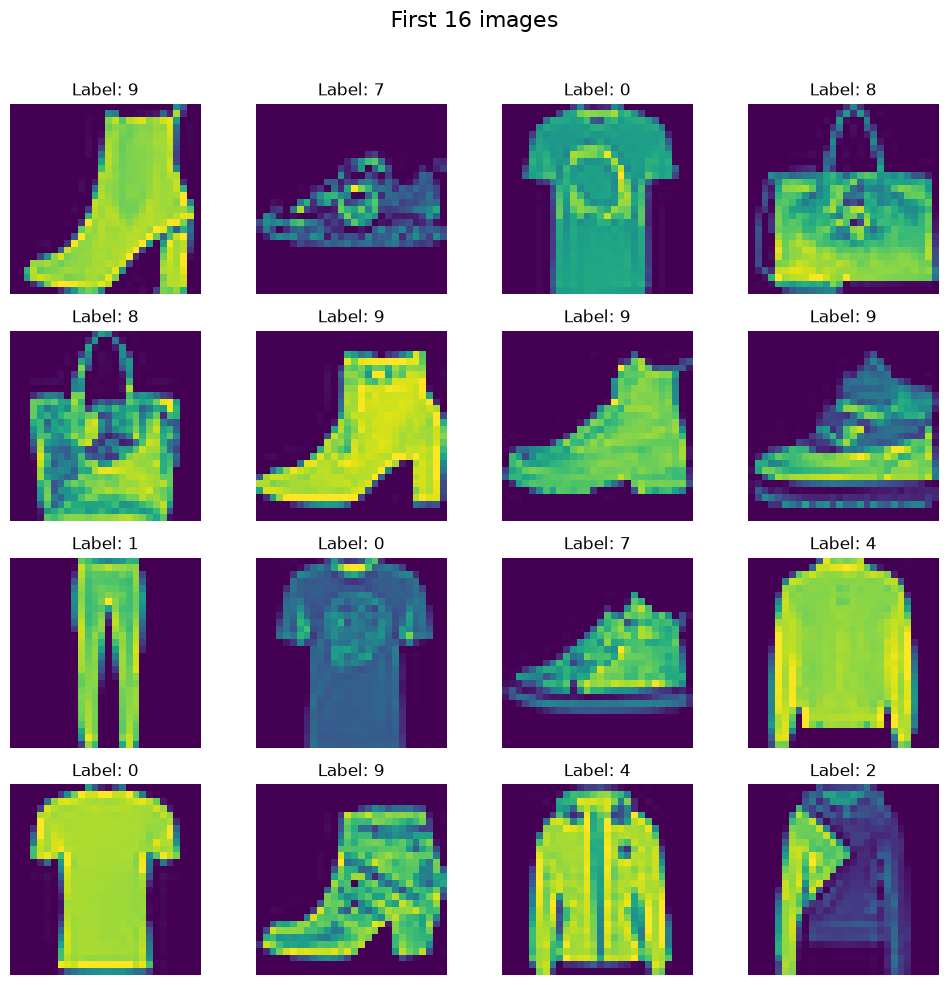

In [50]:
# Create 4x4 (16 images) grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 images", fontsize=16)

# plot the first 16 images from the dataset
for i, ax, in enumerate(axes.flat):
  img = df.iloc[i, 1:].values.reshape(28, 28) # reshape to 28*28
  ax.imshow(img) # display in grayscale
  ax.axis('off') # remove axis for cleaner look
  ax.set_title(f"Label: {df.iloc[i, 0]}") # show the label
  
plt.tight_layout(rect=[0, 0, 1, 0.96]) # adjust layout to fit the title
plt.show()

In [51]:
# train test split
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [53]:
# scaling the features
# in the dataset, the pixel values are within 0 to 255. 
# It is better for neural networking to make the traning values
# between 0 to 1. That's why diving all by 255.
X_train = X_train / 255.0
X_test = X_test / 255.0

In [54]:
# Create CustomDataset Class
class CustomDataset(Dataset):
  def __init__(self, features, labels):
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)
    
  def __len__(self):
    return len(self.features)
  
  def __getitem__(self, index):
    return self.features[index], self.labels[index]

In [55]:
# Create train_dataset object
train_dataset = CustomDataset(X_train, y_train)
len(train_dataset)
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [56]:
test_dataset = CustomDataset(X_test, y_test)

In [57]:
# Create train and test loader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [58]:
# Define NN class
# Do not need to add Softmax for output layer
# In pytoch it is added by default
class MyNN(nn.Module):
  def __init__(self, num_features):
    super().__init__()
    self.model = nn.Sequential(
      nn.Linear(num_features, 128),
      nn.ReLU(),
      nn.Linear(128, 64),
      nn.ReLU(),
      nn.Linear(64, 10)
    )
    
  def forward(self, x):
    return self.model(x)

In [59]:
epochs = 100
learning_rate = 0.1

In [60]:
# Instantiate the model
model = MyNN(X_train.shape[1])

# Loss Function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.SGD(model.parameters(), lr=learning_rate)



In [61]:
# Training Loop
for epoch in range(epochs):
  total_epoch_loss = 0
  for batch_features, batch_labels in train_loader:
    # forward pass
    outputs = model(batch_features)
    
    # calculate loss
    loss = criterion(outputs, batch_labels)
    
    # backpropagation
    optimizer.zero_grad()
    loss.backward()
    
    # gradients update
    optimizer.step()
    
    total_epoch_loss = total_epoch_loss + loss.item()
  
  avg_loss = total_epoch_loss / len(train_loader)
  print(f"Epoch: {epoch + 1}, Loss: {avg_loss}")
    

Epoch: 1, Loss: 1.3216368611653646
Epoch: 2, Loss: 0.7793365440766017
Epoch: 3, Loss: 0.6427524457375209
Epoch: 4, Loss: 0.5751657408475875
Epoch: 5, Loss: 0.527877271771431
Epoch: 6, Loss: 0.4953110021352768
Epoch: 7, Loss: 0.46192685077587764
Epoch: 8, Loss: 0.43552651261289915
Epoch: 9, Loss: 0.4189064414302508
Epoch: 10, Loss: 0.39741519540548326
Epoch: 11, Loss: 0.3866572278738022
Epoch: 12, Loss: 0.371277789970239
Epoch: 13, Loss: 0.3490207254886627
Epoch: 14, Loss: 0.34762981747587524
Epoch: 15, Loss: 0.31585515106717743
Epoch: 16, Loss: 0.3119578692813714
Epoch: 17, Loss: 0.2958236788213253
Epoch: 18, Loss: 0.2882651563485463
Epoch: 19, Loss: 0.2712535859147708
Epoch: 20, Loss: 0.25993845144907635
Epoch: 21, Loss: 0.2577110428114732
Epoch: 22, Loss: 0.24670668331285317
Epoch: 23, Loss: 0.23920487398902576
Epoch: 24, Loss: 0.22485942848026752
Epoch: 25, Loss: 0.22402791308859984
Epoch: 26, Loss: 0.21265137811501822
Epoch: 27, Loss: 0.21999296369651952
Epoch: 28, Loss: 0.21020568

In [63]:
# Set model to eval mode
# this function turns the model into evaluation mode. 
model.eval()
# it prevents the model from dropping off the neurons which sometimes happens in training over a dataset. 

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [64]:
# evaluation code
# will use test dataset for evaluation the model
total = 0
correct = 0

with torch.no_grad(): # as we do not need gradient while predicting 
  for batch_features, batch_labels in test_loader:
    outputs = model(batch_features)
    print(f"Outputs: {outputs}")
    _, predicted = torch.max(outputs, 1)
    print(f"Predicted: {predicted}")
    total = total + batch_labels.shape[0]
    correct = correct + (predicted == batch_labels).sum().item()
  
print(correct / total)

Outputs: tensor([[-1.0701e+01,  1.8643e+00, -1.2339e+01,  1.5464e+00,  2.9190e+00,
          9.3697e+00, -2.4228e+01,  3.3265e+01,  3.3353e+00, -2.7257e+00],
        [ 2.3420e+01, -5.9913e+00,  9.4853e-01, -5.0841e+00, -7.7398e+00,
         -7.3001e+00,  2.3942e+01, -8.7527e+00,  2.5289e-01, -1.3621e+01],
        [-3.1648e+00, -1.4988e+00, -2.0178e+00,  3.7505e-01, -4.8772e-01,
          1.0686e+01, -1.3519e+00,  6.0984e+00, -4.3920e-01, -7.6392e+00],
        [-8.3126e+00, -7.0303e+00,  5.6542e+00, -2.0342e+00,  1.4857e+01,
         -3.4083e+00,  2.2223e+01, -1.2487e+01, -1.8339e+00, -8.9878e+00],
        [ 5.1886e+00,  3.4501e+00, -1.2467e+01,  2.6086e+01, -6.3391e+00,
         -5.5836e+00, -1.6093e+00, -5.5322e+00, -4.8987e+00,  2.4255e-01],
        [-3.1636e+00, -1.7999e-01,  6.0770e+00, -8.8800e-01,  6.7793e+00,
         -9.8300e+00,  3.9787e+00, -1.2729e+00,  4.7685e+00, -5.8282e+00],
        [-5.3916e+00, -8.1055e-01, -7.6399e+00, -9.0004e+00, -2.0751e+00,
          1.2737e+01, -